# 231 — -101 clustering

Loads blob objects from a 230 run, paints -101 maps, downsamples to 10%, clusters with KMeans + HC.

**Inputs** → `outputs/230_blob_clustering_runs/<run_id>/`

**Outputs** → `outputs/231_minus101_clustering_runs/<run_id>/`

In [14]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from functions import lf_blob_clustering_config as cfg
from functions.lf_clustering import s10_load_ersps
from functions.lf_minus101 import (
    s23_build_minus101_feature_matrix,
    q60_plot_minus101_overlays,
    q61_plot_minus101_prototype,
)
from functions.lf_blob_metrics import s22_build_blob_feature_matrix
from functions.lf_clustering_methods import (
    s50_run_kmeans,
    s51_run_hc,
    s52_cut_hc,
    s53_compute_medoids,
    s54_compute_prototypes,
    s55_build_df_with_clusters,
    s71_save_run,
    q50_plot_silhouette_curve,
    q51_plot_dendrogram,
    q52_plot_prototype_grid,
)

BASE_RUNS_DIR = Path('outputs/231_minus101_clustering_runs')
BASE_RUNS_DIR.mkdir(parents=True, exist_ok=True)

## Config

In [15]:
# ── link to 230 run ──────────────────────────────────────────
# Point to a specific 230 run to reuse its blob objects and gating
RUN_ID_230   = None   # set to a run_id string e.g. '20250101_120000', or None to use latest
RUNS_DIR_230 = Path('outputs/230_blob_clustering_runs')
print(RUNS_DIR_230)
# ── data input (same as 230) ─────────────────────────────────
INPUT_DIR  = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY')
TASK       = 'LM'
CONDITIONS = ('audio', 'picture', 'reading')
N_FREQ, N_TIME = 129, 300

# ── segmentation (same params as 230) ────────────────────────
VALLEY_PARAMS = cfg.VALLEY_PARAMS

# ── -101 downsampling ────────────────────────────────────────
SCALE = 0.10   # 10% of original — gives 13×30 = 390 features

# ── score gate (inherited from 230 run) ──────────────────────
# Applied when rebuilding blobs — keeps only blobs above this score
SCORE_MIN = None   # set to a float to gate, or None to keep all

# ── clustering ───────────────────────────────────────────────
KMEANS_K_RANGE = cfg.KMEANS_K_RANGE
HC_METHOD      = 'average'
HC_N_CLUSTERS  = 20
RANDOM_STATE   = cfg.RANDOM_STATE

print('VALLEY_PARAMS:', VALLEY_PARAMS)
print('SCALE:', SCALE)
print('KMEANS_K_RANGE:', KMEANS_K_RANGE)

outputs\230_blob_clustering_runs
VALLEY_PARAMS: {'thr_pos': 2.5, 'thr_neg': -3.5, 'delta_valley': 1.5, 'min_mean_pos': 1.75, 'max_mean_neg': -2.8000000000000003, 'max_blobs': 6, 'sign_mode': 'both'}
SCALE: 0.1
KMEANS_K_RANGE: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## 1 — Load 230 run (gating + blob objects)

In [16]:
sorted(RUNS_DIR_230.glob('*'))

[WindowsPath('outputs/230_blob_clustering_runs/20260416_214032')]

In [17]:
# Resolve 230 run directory
if RUN_ID_230 is None:
    run_dirs = sorted(RUNS_DIR_230.glob('*'))
    run_dir_230 = run_dirs[0]
    print('Using latest 230 run:', run_dir_230.name)
else:
    run_dir_230 = RUNS_DIR_230 / str(RUN_ID_230)
    print('Using 230 run:', run_dir_230.name)

# Load gated metadata and keep_idx
df_keep   = pd.read_parquet(run_dir_230 / 'df_keep.parquet')
keep_idx  = np.load(run_dir_230 / 'keep_idx.npy')
ersp_keep = np.load(run_dir_230 / 'ersp_keep.npy')   # (n_keep, n_freq, n_time)

ersp_keep_list = [ersp_keep[i] for i in range(len(ersp_keep))]
print('df_keep:', df_keep.shape, '  ersp_keep:', ersp_keep.shape)

Using latest 230 run: 20260416_214032
df_keep: (263, 8)   ersp_keep: (263, 129, 300)


## 2 — Rebuild blob objects (shared segmentation)

In [18]:
# Rerun segmentation on the kept ERSPs to get blobs_per_sample
# These are the SAME blob objects used in 230 — shared segmentation foundation
_, _, blobs_per_sample = s22_build_blob_feature_matrix(
    ersp_list=ersp_keep_list,
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    thr_pos=float(VALLEY_PARAMS['thr_pos']),
    thr_neg=float(VALLEY_PARAMS['thr_neg']),
    delta_valley=float(VALLEY_PARAMS['delta_valley']),
    min_mean_pos=float(VALLEY_PARAMS['min_mean_pos']),
    max_mean_neg=float(VALLEY_PARAMS['max_mean_neg']),
    sign_mode=str(VALLEY_PARAMS['sign_mode']),
)
print('blobs_per_sample ready — n samples:', len(blobs_per_sample))

Valley-blob feature matrix: X_blob.shape=(263, 48) (max_blobs=6, features_per_blob=8)
blobs_per_sample ready — n samples: 263


## 3 — Build -101 feature matrix

In [19]:
X_101, ds_shape = s23_build_minus101_feature_matrix(
    ersp_list=ersp_keep_list,
    blobs_per_sample=blobs_per_sample,
    scale=SCALE,
    score_min=SCORE_MIN,
)
print('X_101:', X_101.shape, '  ds_shape:', ds_shape)

[s23_build_minus101_feature_matrix]
  Original map : 129×300 = 38700 bins
  Downsampled  : 13×30 = 390 features  (scale=10%)
  X_101.shape  : (263, 390)
  Samples with any blob activity: 263/263
X_101: (263, 390)   ds_shape: (13, 30)


## 4 — QC: painted -101 maps

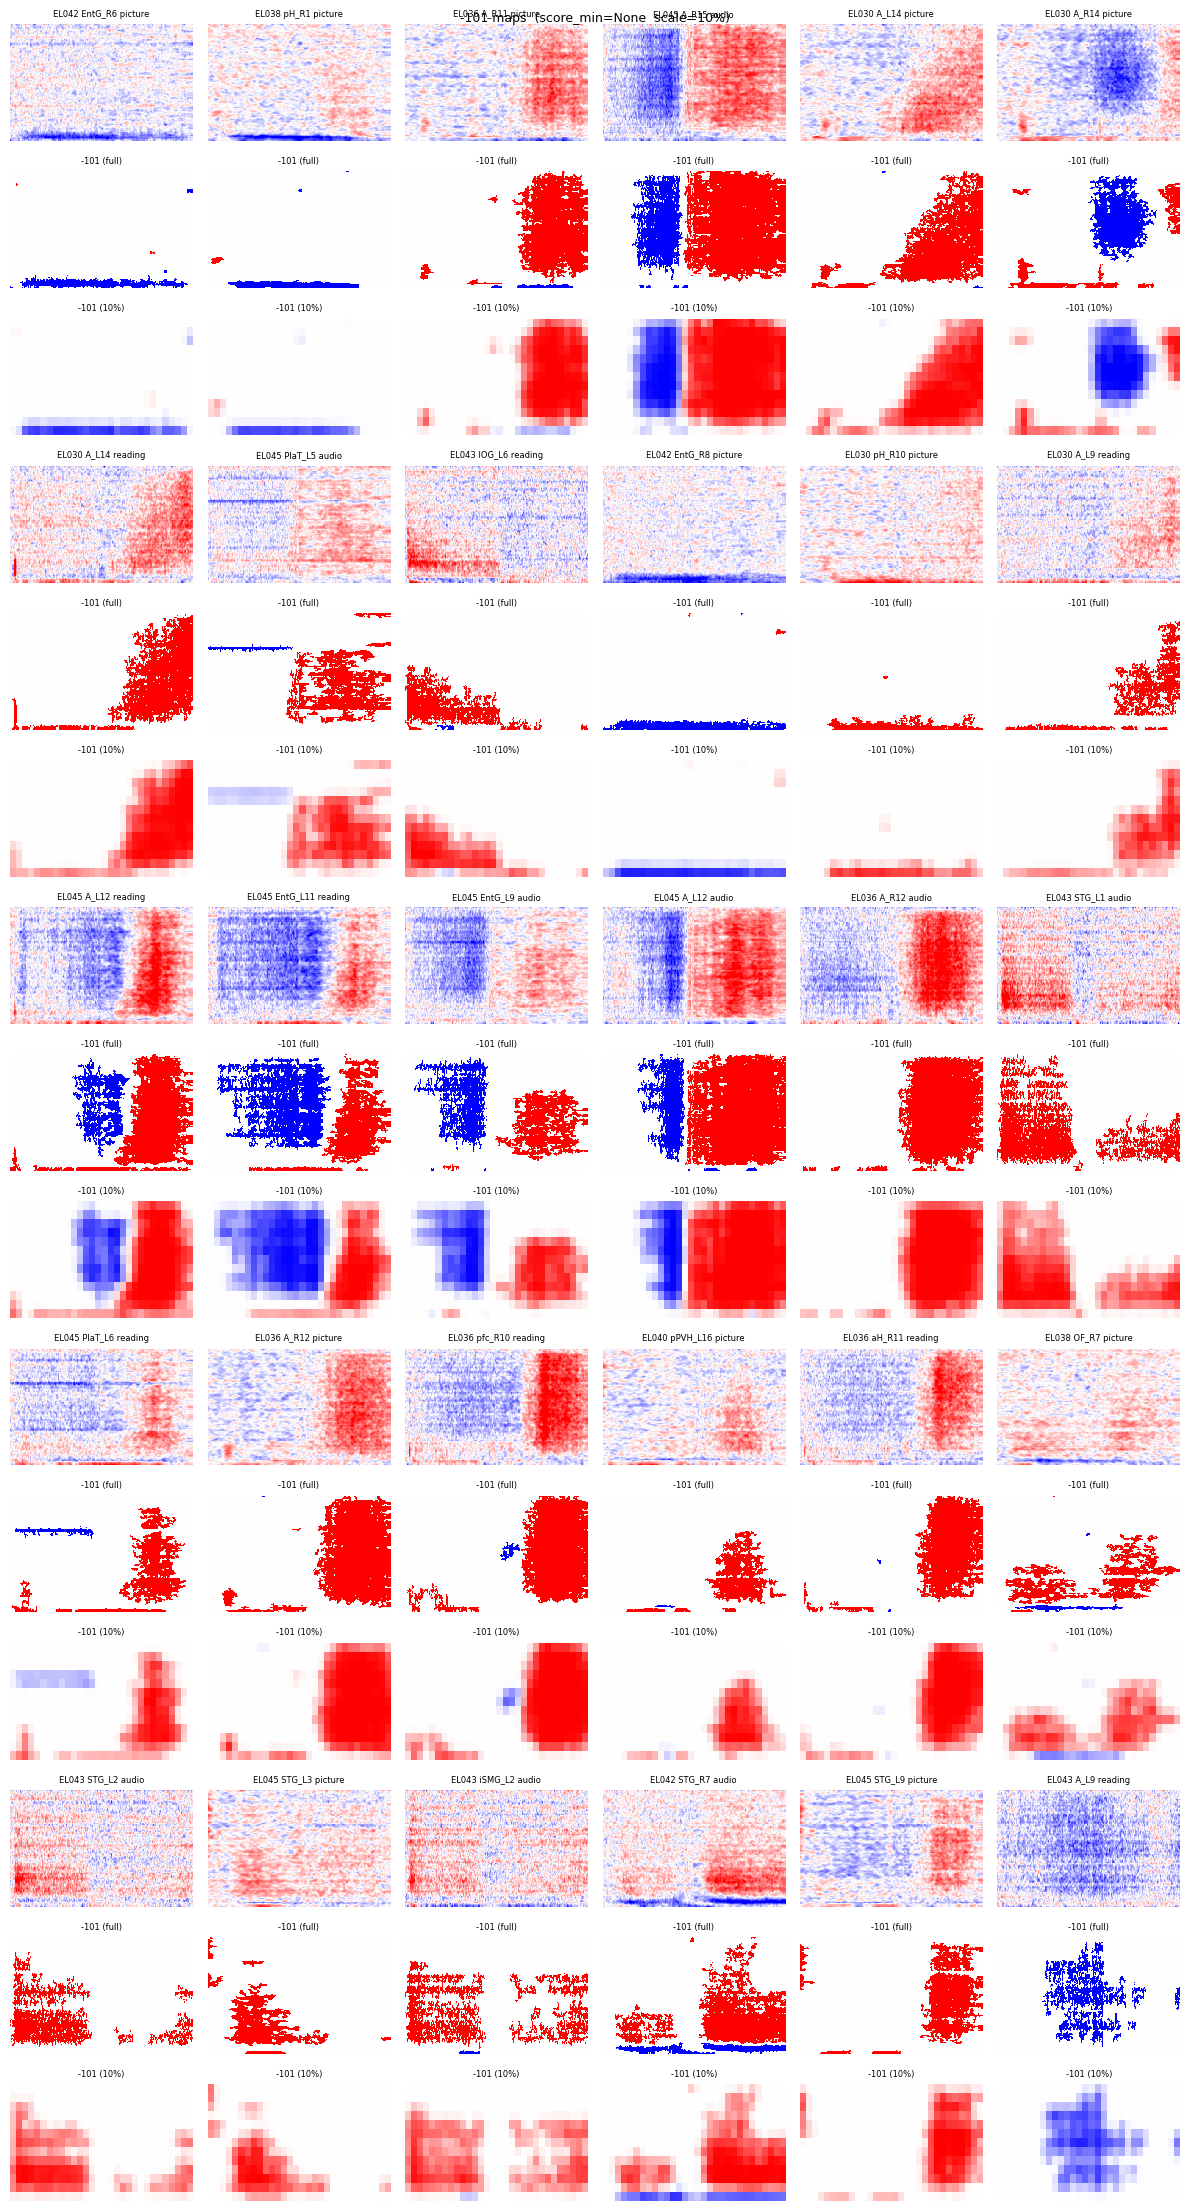

In [20]:
# Sample 30 random indices for visual inspection
rng = np.random.default_rng(42)
qc_idx = rng.choice(len(ersp_keep_list), size=min(30, len(ersp_keep_list)), replace=False).tolist()

q60_plot_minus101_overlays(
    indices=qc_idx,
    ersp_list=ersp_keep_list,
    blobs_per_sample=blobs_per_sample,
    df_meta=df_keep,
    scale=SCALE,
    score_min=SCORE_MIN,
)

## 5 — KMeans clustering

In [21]:
labels_km, best_k, sil_by_k, labels_by_k = s50_run_kmeans(
    Xw=X_101,
    k_range=KMEANS_K_RANGE,
    random_state=RANDOM_STATE,
)

  K= 13  sil=0.2260
  K= 14  sil=0.2086
  K= 15  sil=0.2259
  K= 16  sil=0.2315
  K= 17  sil=0.2243
  K= 18  sil=0.2126
  K= 19  sil=0.2326
  K= 20  sil=0.2274
  K= 21  sil=0.2194
  K= 22  sil=0.2165
  K= 23  sil=0.2294
  K= 24  sil=0.2328
  K= 25  sil=0.2203

[KMeans] Best K=24  silhouette=0.2328


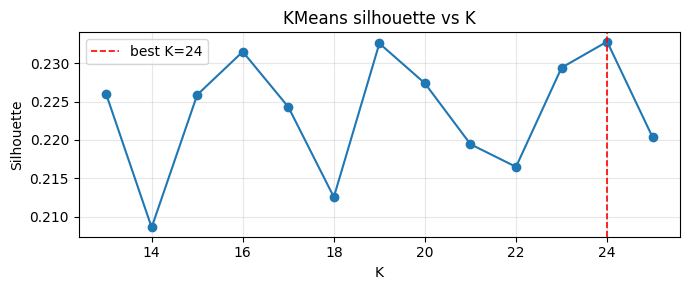

In [22]:
q50_plot_silhouette_curve(sil_by_k, best_k)

## 6 — Hierarchical clustering

In [23]:
Z, D = s51_run_hc(X_101, method=HC_METHOD)

[HC] method=average  metric=euclidean  n=263  cophenetic_r=0.821


\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\functions\lf_clustering_methods.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


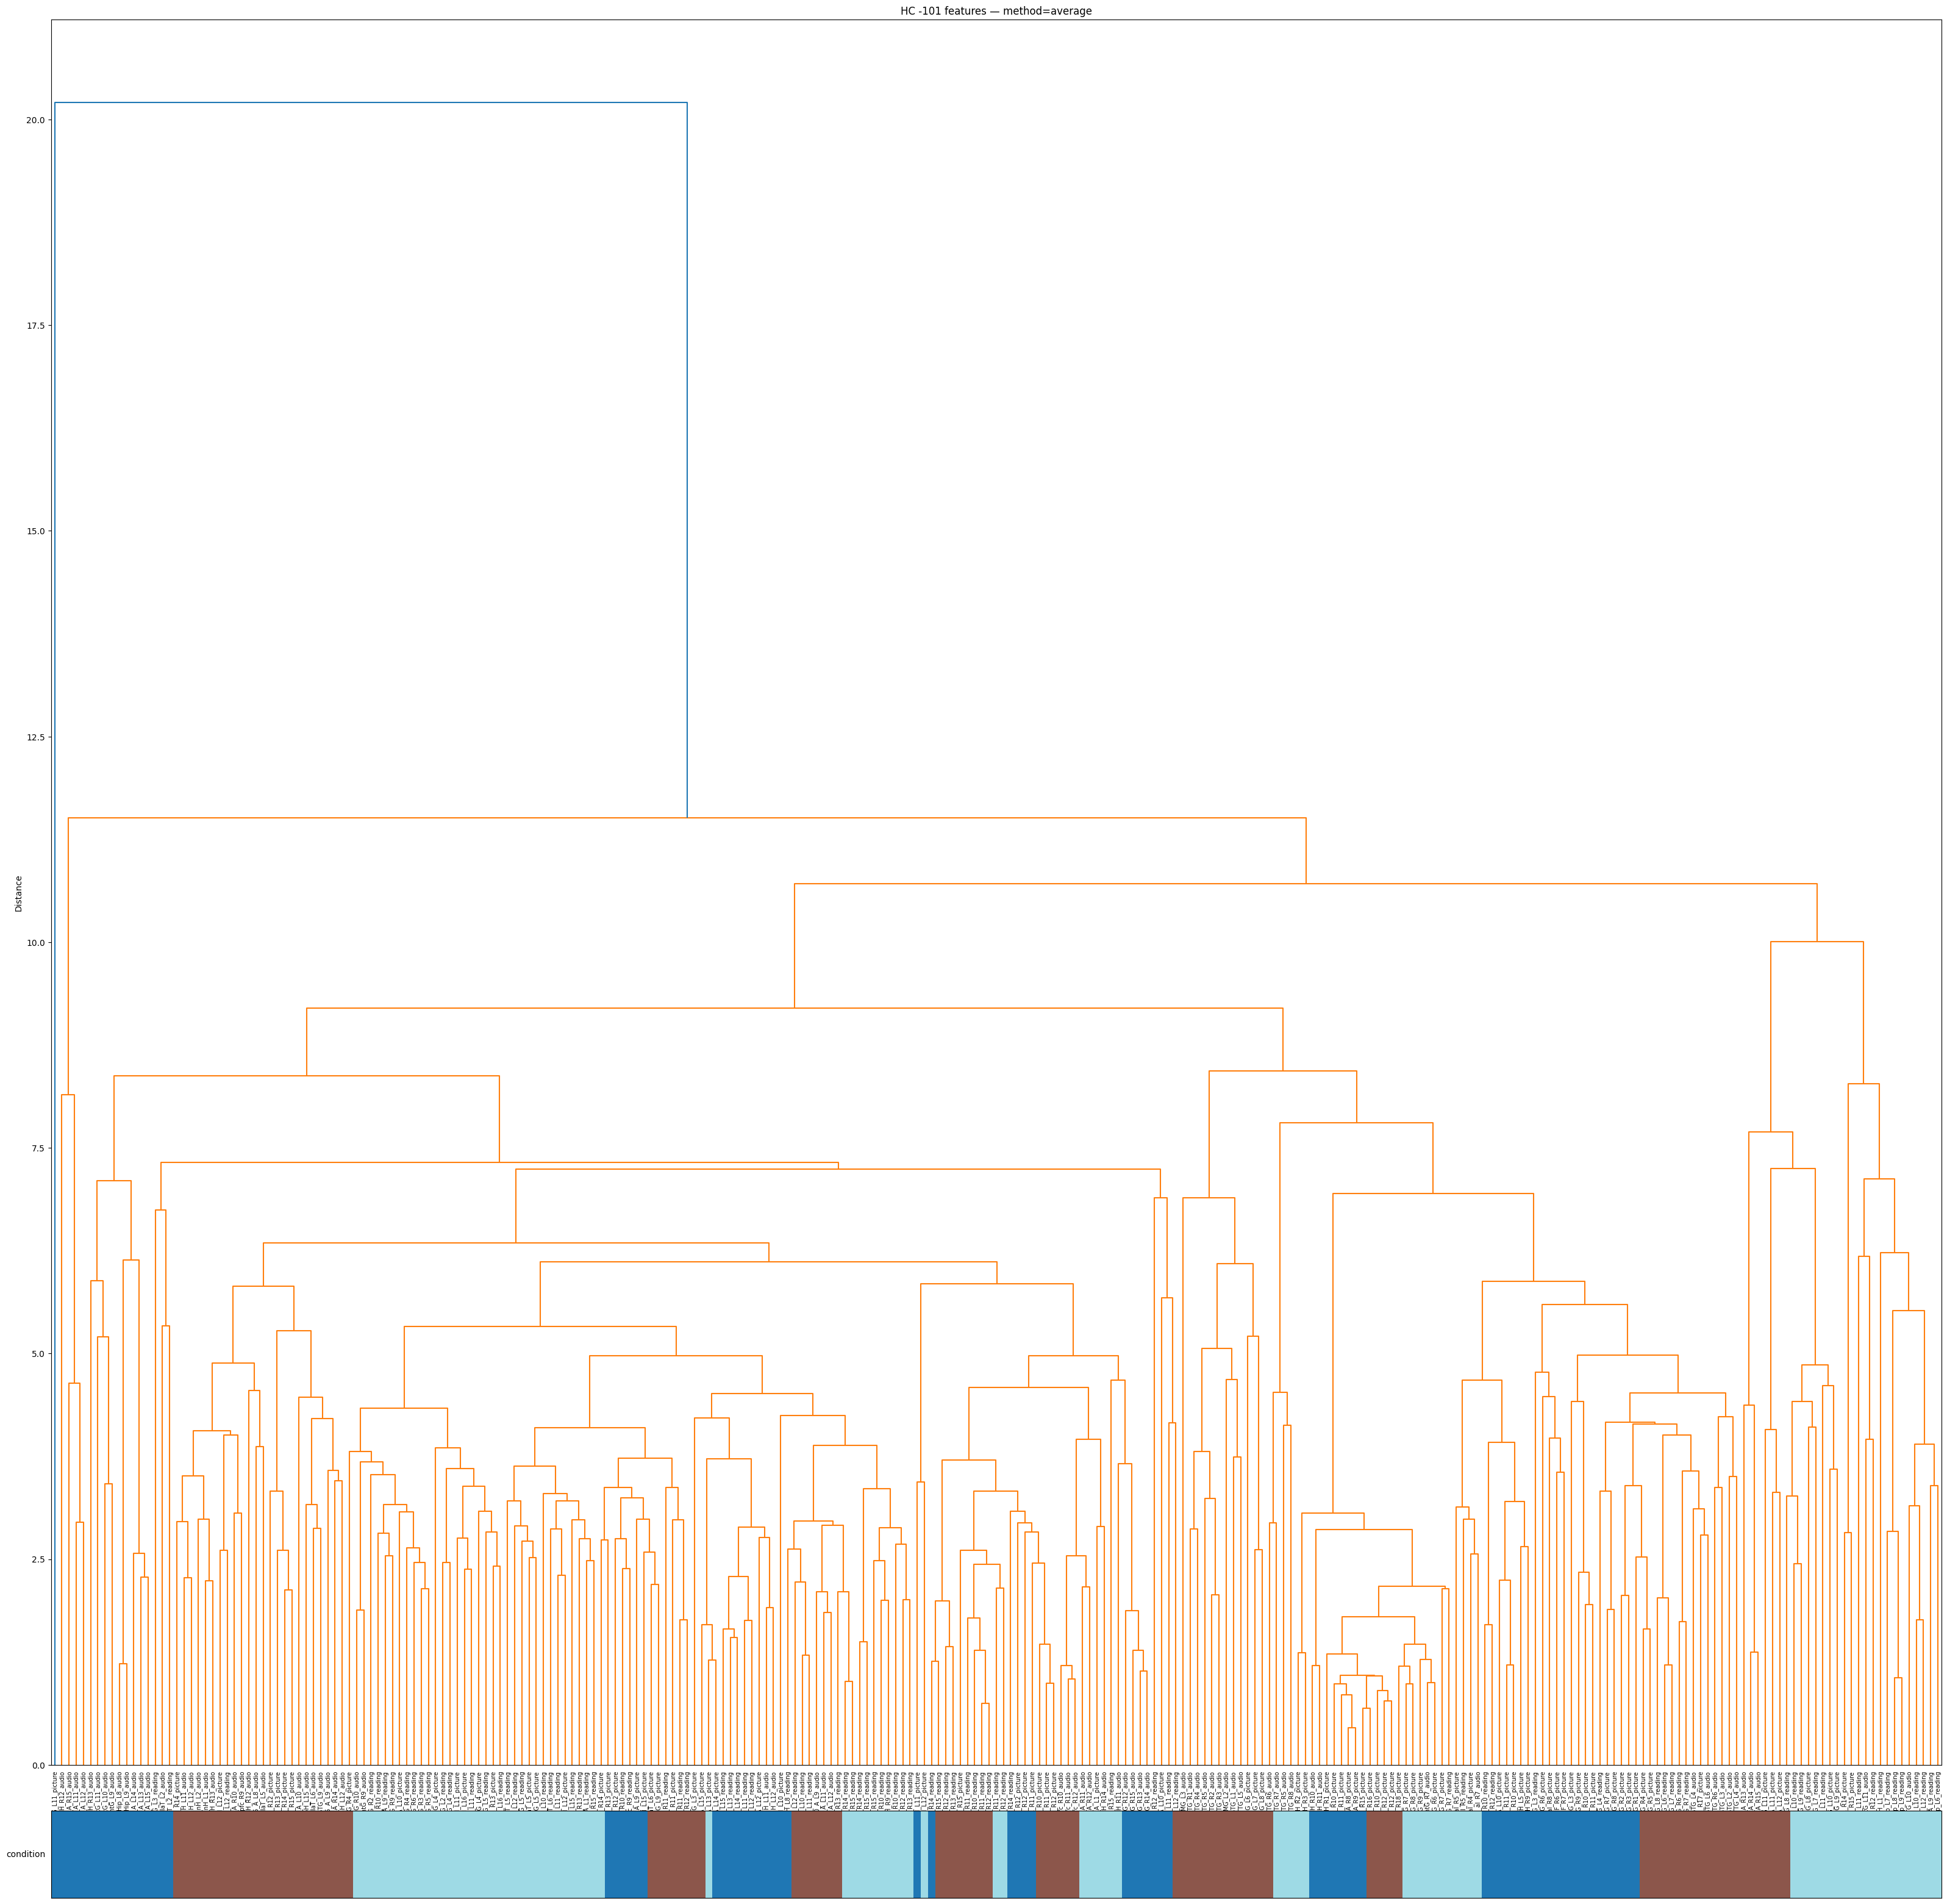

In [24]:
df_keep['leaf_label'] = (
    df_keep['patient_id'].astype(str) + '_' +
    df_keep['electrode'].astype(str) + '_' +
    df_keep['condition'].astype(str)
)

q51_plot_dendrogram(
    Z=Z,
    df_leaf=df_keep,
    strip_col='condition',
    title=f'HC -101 features — method={HC_METHOD}',
)

In [25]:
labels_hc = s52_cut_hc(Z, n_clusters=HC_N_CLUSTERS)
print('HC labels — unique clusters:', len(np.unique(labels_hc)))

HC labels — unique clusters: 20


## 7 — Medoids + prototypes

In [26]:
medoids_km = s53_compute_medoids(D, labels_km)
medoids_hc = s53_compute_medoids(D, labels_hc)

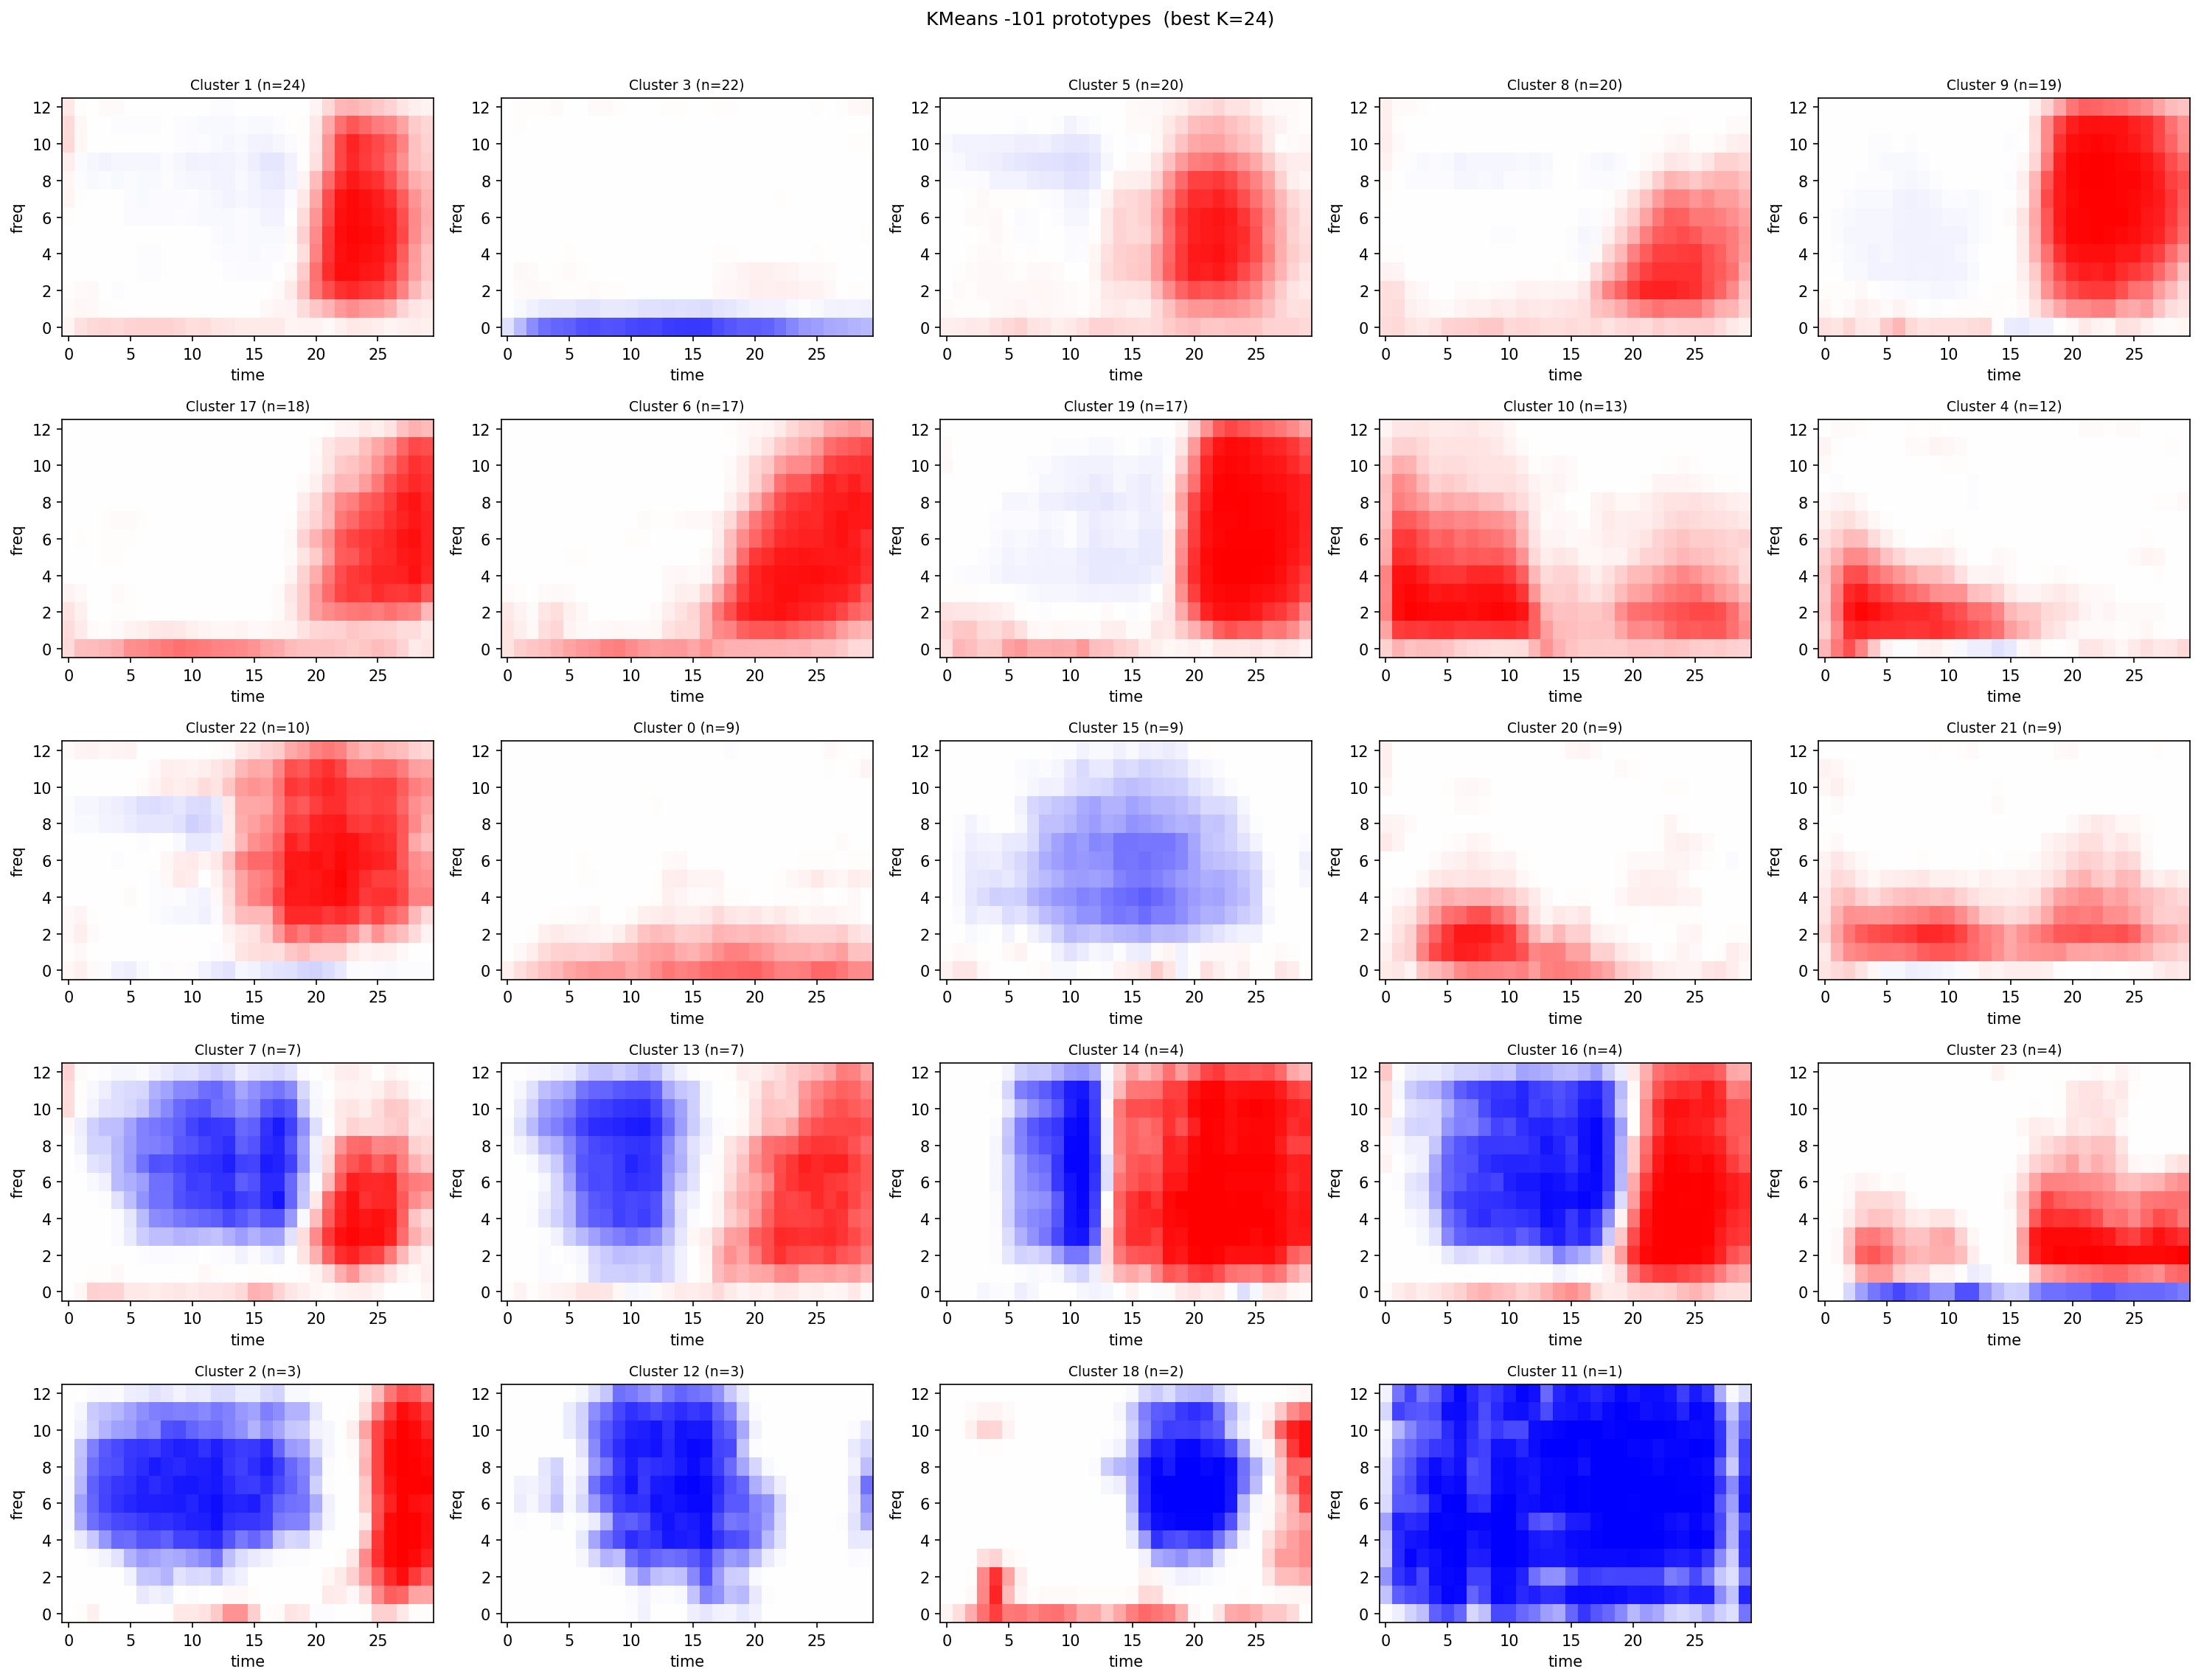

In [27]:
# Mean -101 prototype per cluster (reshape from flat back to ds_shape)
proto_km = {
    c: X_101[labels_km == c].mean(axis=0).reshape(ds_shape)
    for c in np.unique(labels_km)
}
proto_hc = {
    c: X_101[labels_hc == c].mean(axis=0).reshape(ds_shape)
    for c in np.unique(labels_hc)
}

q52_plot_prototype_grid(
    proto_mean=proto_km,
    labels=labels_km,
    title=f'KMeans -101 prototypes  (best K={best_k})',
)

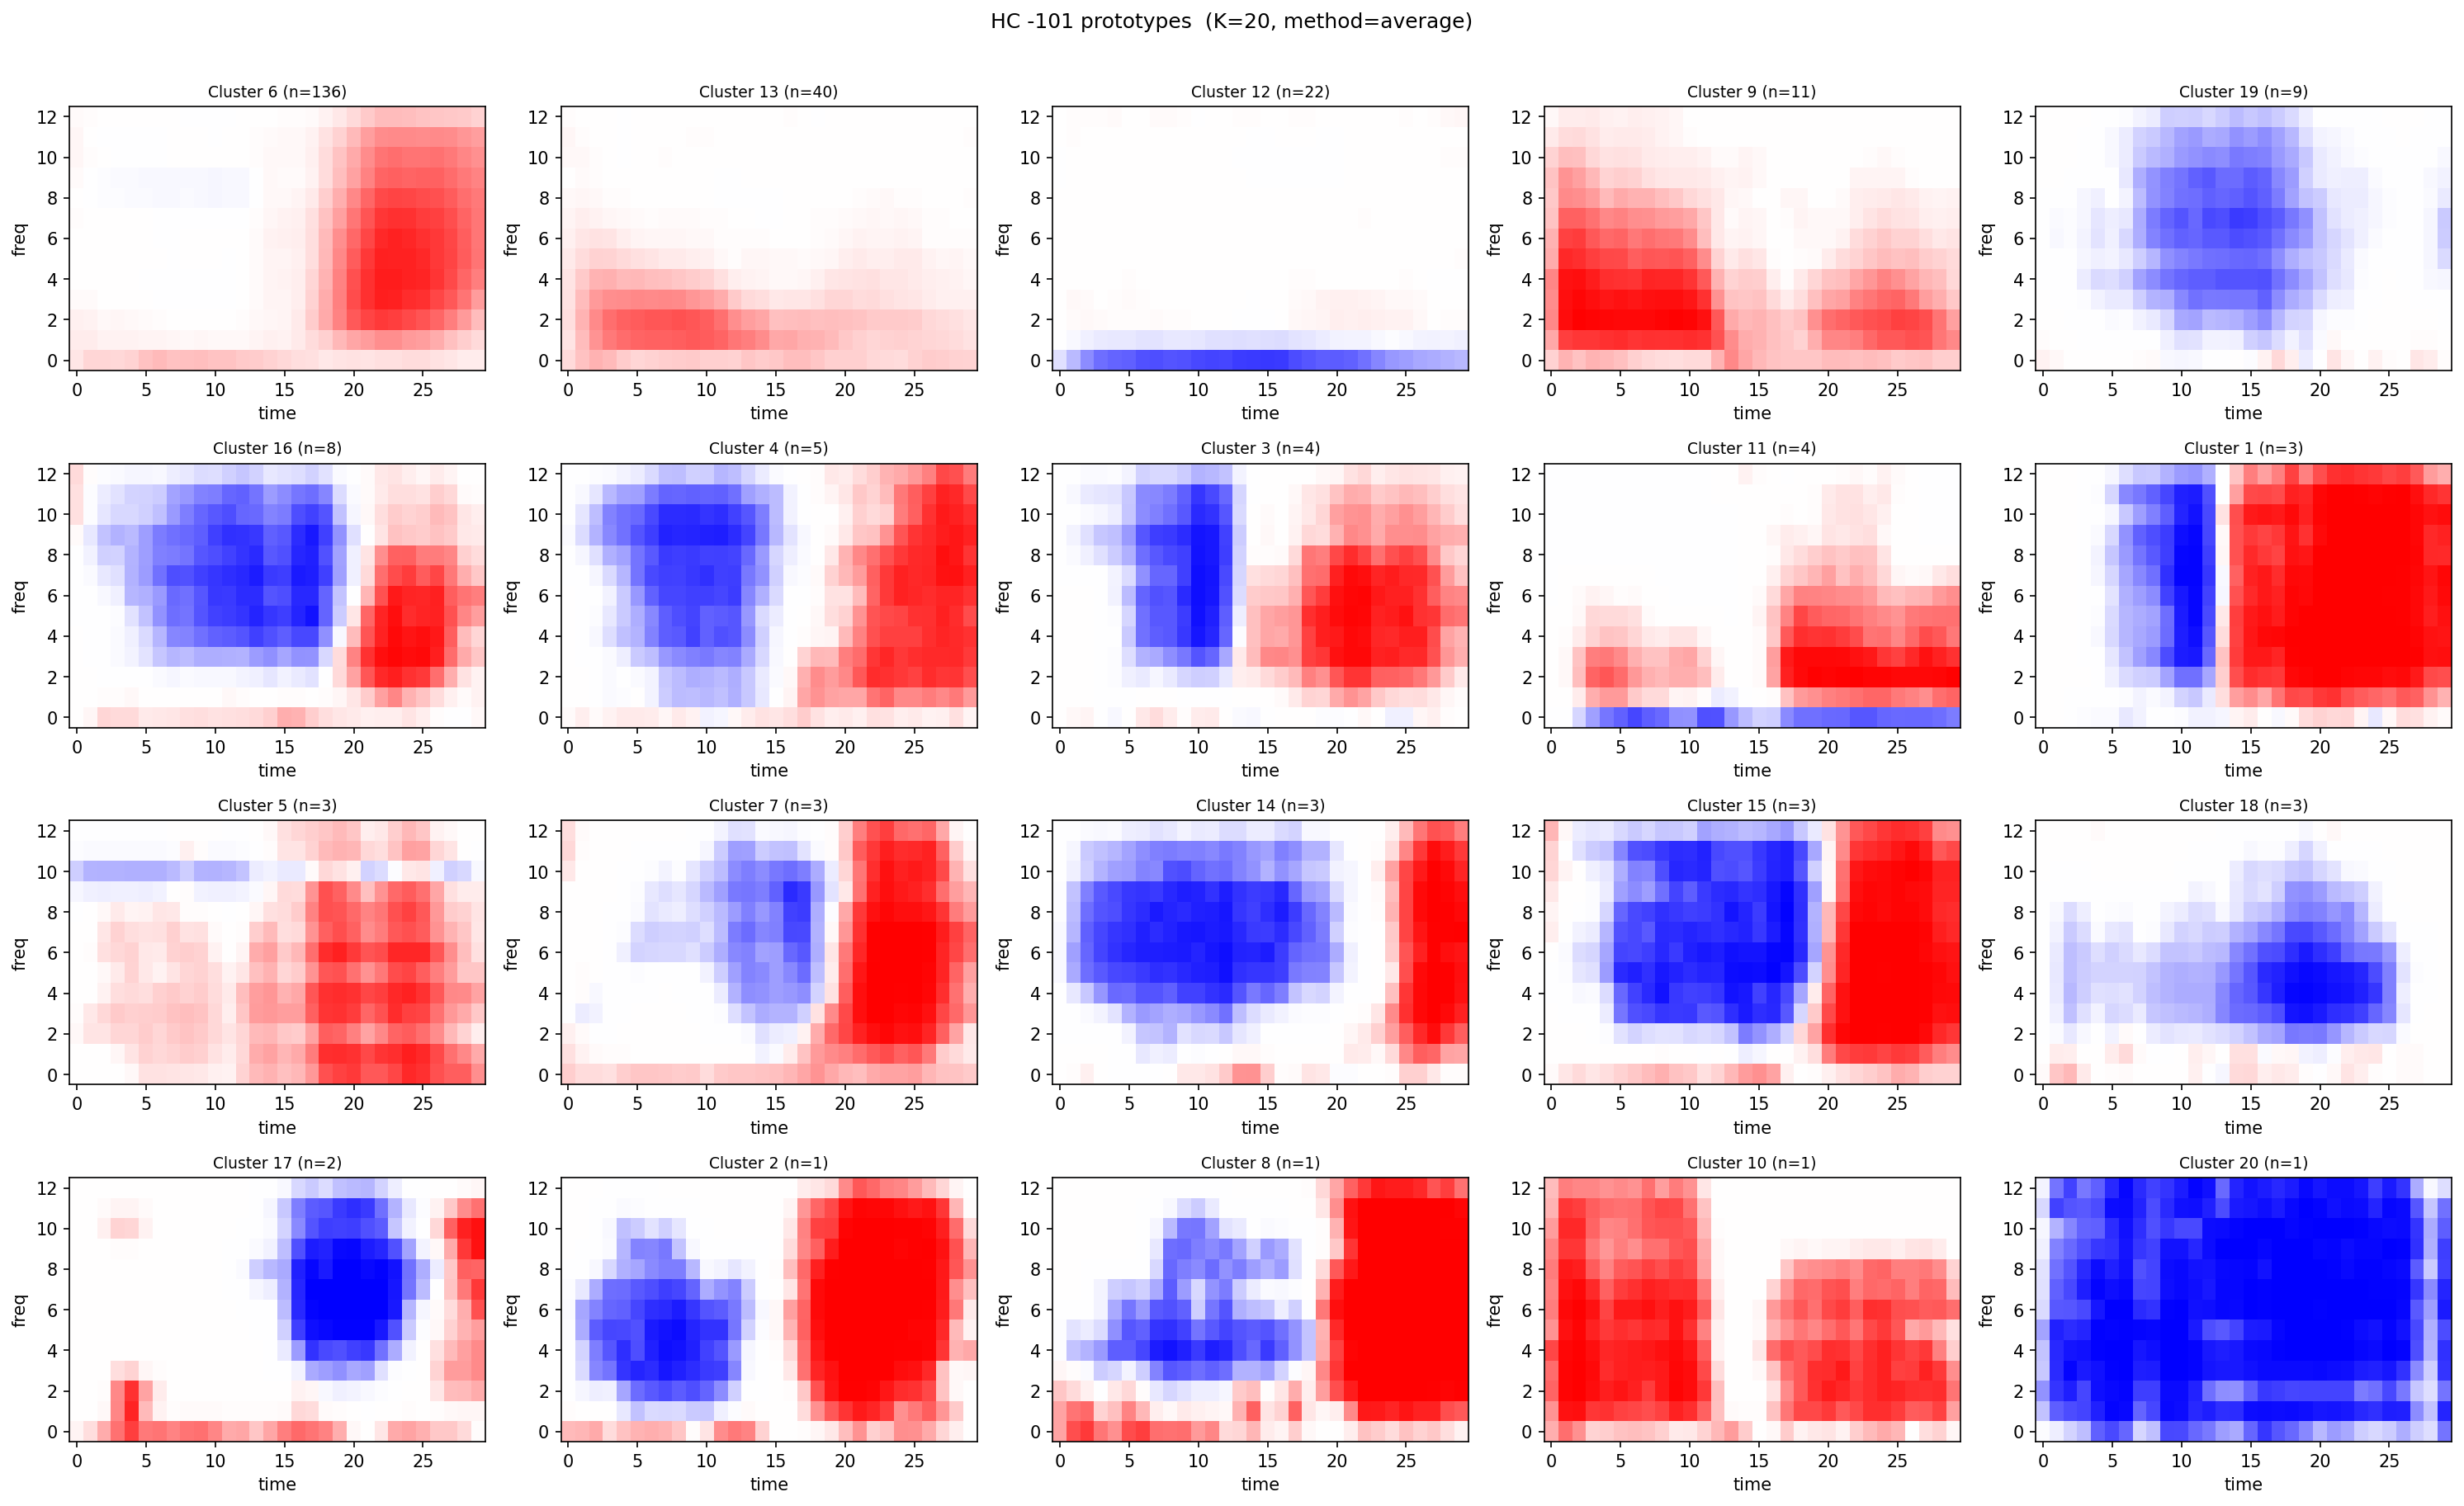

In [28]:
q52_plot_prototype_grid(
    proto_mean=proto_hc,
    labels=labels_hc,
    title=f'HC -101 prototypes  (K={HC_N_CLUSTERS}, method={HC_METHOD})',
)

## 8 — Save run

In [29]:
from datetime import datetime
run_id = datetime.now().strftime('%Y%m%d_%H%M%S')
run_dir = BASE_RUNS_DIR / run_id
run_dir.mkdir(parents=True, exist_ok=True)

# Save X_101 and ds_shape
np.save(run_dir / 'X_101.npy', X_101)
np.save(run_dir / 'ds_shape.npy', np.array(ds_shape))

print('Run dir:', run_dir)

Run dir: outputs\231_minus101_clustering_runs\20260417_085145


In [30]:
# KMeans
param_tag_km = f'k{best_k}_scale{int(SCALE*100)}pct'
df_km = s55_build_df_with_clusters(
    df_keep=df_keep,
    labels=labels_km,
    algo_tag='kmeans_101',
    param_tag=param_tag_km,
    keep_idx=keep_idx,
)

s71_save_run(
    run_dir=run_dir,
    df_keep_with_clusters=df_km,
    labels=labels_km,
    algo_tag='kmeans_101',
    param_tag=param_tag_km,
    sil_by_k=sil_by_k,
    labels_by_k=labels_by_k,
    extra_meta={
        'run_id_230': str(run_dir_230.name),
        'scale': SCALE,
        'ds_shape': list(ds_shape),
        'valley_params': VALLEY_PARAMS,
        'score_min': SCORE_MIN,
    },
)

[s71_save_run] Saved to: outputs\231_minus101_clustering_runs\20260417_085145
  algo=kmeans_101  param=k24_scale10pct  n_clusters=24
  files in run_dir: 19


WindowsPath('outputs/231_minus101_clustering_runs/20260417_085145')

In [31]:
# HC
param_tag_hc = f'k{HC_N_CLUSTERS}_{HC_METHOD}_scale{int(SCALE*100)}pct'
df_hc = s55_build_df_with_clusters(
    df_keep=df_keep,
    labels=labels_hc,
    algo_tag='hc_101',
    param_tag=param_tag_hc,
    keep_idx=keep_idx,
)

s71_save_run(
    run_dir=run_dir,
    df_keep_with_clusters=df_hc,
    labels=labels_hc,
    algo_tag='hc_101',
    param_tag=param_tag_hc,
    Z=Z,
    D=D,
    extra_meta={
        'run_id_230': str(run_dir_230.name),
        'scale': SCALE,
        'ds_shape': list(ds_shape),
        'valley_params': VALLEY_PARAMS,
        'hc_method': HC_METHOD,
        'hc_n_clusters': HC_N_CLUSTERS,
        'score_min': SCORE_MIN,
    },
)
print('Done — run saved to:', run_dir)

[s71_save_run] Saved to: outputs\231_minus101_clustering_runs\20260417_085145
  algo=hc_101  param=k20_average_scale10pct  n_clusters=20
  files in run_dir: 22
Done — run saved to: outputs\231_minus101_clustering_runs\20260417_085145


In [33]:
# After s71_save_run for KMeans:
df_km.to_csv(run_dir / f'labels_{param_tag_km}.csv', index=False)

# After s71_save_run for HC:
df_hc.to_csv(run_dir / f'labels_{param_tag_hc}.csv', index=False)